<a href="https://colab.research.google.com/github/Kriti-2180/Deep-Learning/blob/main/MLPmemorizationP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
X_train = np.array([
    [1, 4, 50],
    [2, 5, 55],
    [3, 5, 60],
    [4, 6, 65],
    [5, 7, 75],
    [6, 7, 80],
    [7, 8, 85],
    [8, 8, 90],
    [9, 8, 95],
    [10, 9, 98]
], dtype=float)

y_train = np.array([
    0, 1, 0, 0, 1, 0, 1, 1, 1, 1
], dtype=float)

In [ ]:
X_test = np.array([
    [1.5, 4.5, 52],
    [2.5, 5.5, 58],
    [3.5, 5.5, 63],
    [4.5, 6.5, 70],
    [5.5, 7.5, 78],
    [6.5, 7.5, 82],
    [7.5, 8.5, 88],
    [8.5, 8.5, 92]
], dtype=float)

y_test = np.array([
    0, 0, 0, 1, 1, 1, 1, 1
], dtype=float)

In [ ]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[:, 0] /= 10
X_train_scaled[:, 1] /= 10
X_train_scaled[:, 2] /= 100

X_test_scaled[:, 0] /= 10
X_test_scaled[:, 1] /= 10
X_test_scaled[:, 2] /= 100

In [ ]:
#Big MLP model
model = Sequential([
    Dense(64, activation='relu', input_shape=(3,)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=300,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4000 - loss: 0.7059 - val_accuracy: 0.3750 - val_loss: 0.6983
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4000 - loss: 0.6970 - val_accuracy: 0.6250 - val_loss: 0.6885
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6000 - loss: 0.6889 - val_accuracy: 0.6250 - val_loss: 0.6794
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.6000 - loss: 0.6814 - val_accuracy: 0.6250 - val_loss: 0.6704
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6000 - loss: 0.6744 - val_accuracy: 0.6250 - val_loss: 0.6616
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6000 - loss: 0.6679 - val_accuracy: 0.6250 - val_loss: 0.6542
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6000 - loss: 0.6617 - val_accuracy: 0.6250 - val_loss: 0.6483
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6000 - loss: 0.6573 - val_accuracy: 0.6250 - val_loss: 0

In [ ]:
train_loss, train_acc = model.evaluate(
    X_train_scaled,
    y_train,
    verbose=0
)

test_loss, test_acc = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

print("Training Loss:", train_loss)
print("Testing Loss:", test_loss)

Training Accuracy: 1.0
Testing Accuracy: 0.875
Training Loss: 0.2334960252046585
Testing Loss: 0.3191203474998474


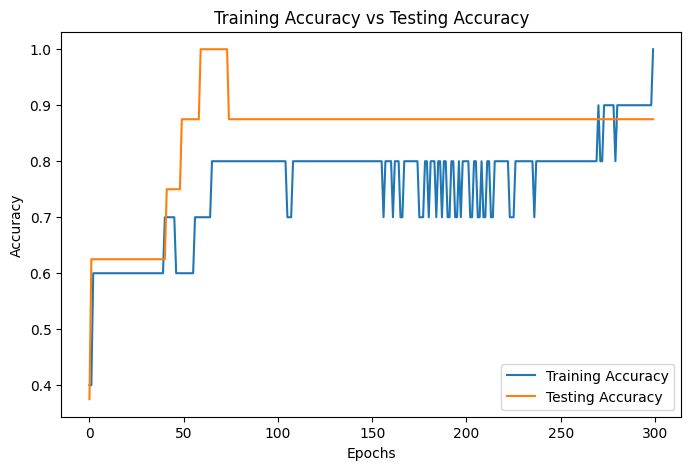

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Testing Accuracy'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Testing Accuracy")

plt.legend()
plt.show()

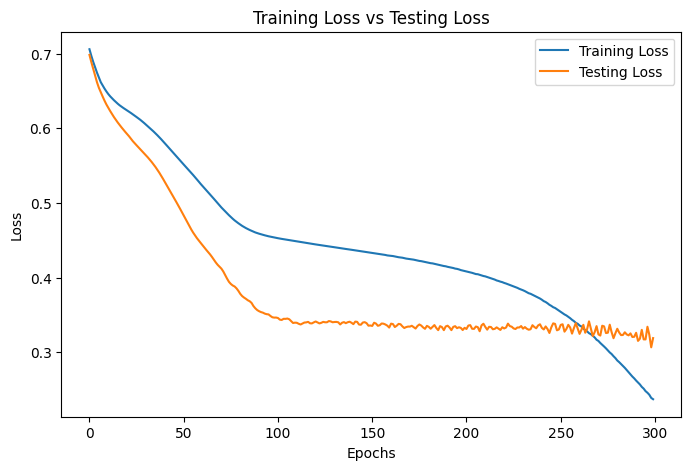

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Testing Loss'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Testing Loss")

plt.legend()
plt.show()

In [ ]:
predictions = model.predict(X_test_scaled)

for i in range(len(X_test_scaled)):

    probability = predictions[i][0]

    predicted_class = 1 if probability >= 0.5 else 0

    print(
        "Student:",
        X_test[i],
        "| Actual:",
        int(y_test[i]),
        "| Probability:",
        round(probability, 3),
        "| Predicted:",
        predicted_class
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Student: [ 1.5  4.5 52. ] | Actual: 0 | Probability: 0.334 | Predicted: 0
Student: [ 2.5  5.5 58. ] | Actual: 0 | Probability: 0.436 | Predicted: 0
Student: [ 3.5  5.5 63. ] | Actual: 0 | Probability: 0.144 | Predicted: 0
Student: [ 4.5  6.5 70. ] | Actual: 1 | Probability: 0.326 | Predicted: 0
Student: [ 5.5  7.5 78. ] | Actual: 1 | Probability: 0.887 | Predicted: 1
Student: [ 6.5  7.5 82. ] | Actual: 1 | Probability: 0.844 | Predicted: 1
Student: [ 7.5  8.5 88. ] | Actual: 1 | Probability: 0.996 | Predicted: 1
Student: [ 8.5  8.5 92. ] | Actual: 1 | Probability: 0.996 | Predicted: 1


In [ ]:
small_model = Sequential([
    Dense(4, activation='relu', input_shape=(3,)),
    Dense(1, activation='sigmoid')
])

small_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

small_history = small_model.fit(
    X_train_scaled,
    y_train,
    epochs=300,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 683ms/step - accuracy: 0.6000 - loss: 0.6426 - val_accuracy: 0.6250 - val_loss: 0.5884
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6000 - loss: 0.6417 - val_accuracy: 0.6250 - val_loss: 0.5879
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6000 - loss: 0.6407 - val_accuracy: 0.6250 - val_loss: 0.5873
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6000 - loss: 0.6398 - val_accuracy: 0.6250 - val_loss: 0.5868
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6000 - loss: 0.6389 - val_accuracy: 0.6250 - val_loss: 0.5863
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6000 - loss: 0.6380 - val_accuracy: 0.6250 - val_loss: 0.5858
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6000 - loss: 0.6371 - val_accuracy: 0.6250 - val_loss: 0.5853
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6000 - loss: 0.6363 - val_accuracy: 0.6250 - val_loss

In [ ]:
#Small MLP model

small_model = Sequential([
    Dense(4, activation='relu', input_shape=(3,)),
    Dense(1, activation='sigmoid')
])

small_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

small_history = small_model.fit(
    X_train_scaled,
    y_train,
    epochs=300,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 670ms/step - accuracy: 0.6000 - loss: 0.6460 - val_accuracy: 0.6250 - val_loss: 0.6186
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6000 - loss: 0.6458 - val_accuracy: 0.6250 - val_loss: 0.6183
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6000 - loss: 0.6455 - val_accuracy: 0.6250 - val_loss: 0.6181
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6000 - loss: 0.6452 - val_accuracy: 0.6250 - val_loss: 0.6178
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6000 - loss: 0.6449 - val_accuracy: 0.6250 - val_loss: 0.6175
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6000 - loss: 0.6446 - val_accuracy: 0.6250 - val_loss: 0.6173
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6000 - loss: 0.6443 - val_accuracy: 0.6250 - val_loss: 0.6170
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6000 - loss: 0.6440 - val_accuracy: 0.6250 - val_loss

In [ ]:
small_train_loss, small_train_acc = small_model.evaluate(
    X_train_scaled,
    y_train,
    verbose=0
)

small_test_loss, small_test_acc = small_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Small Model Training Accuracy:", small_train_acc)
print("Small Model Testing Accuracy:", small_test_acc)

Small Model Training Accuracy: 0.699999988079071
Small Model Testing Accuracy: 0.75


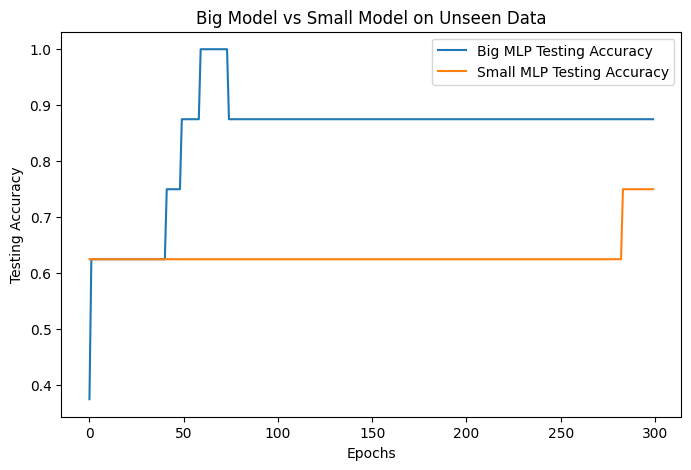

In [ ]:
# Compare Big Model vs Small Model

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['val_accuracy'],
    label='Big MLP Testing Accuracy'
)

plt.plot(
    small_history.history['val_accuracy'],
    label='Small MLP Testing Accuracy'
)

plt.xlabel("Epochs")
plt.ylabel("Testing Accuracy")
plt.title("Big Model vs Small Model on Unseen Data")

plt.legend()
plt.show()

In [ ]:
# Add Dropout to reduce memorization

from tensorflow.keras.layers import Dropout

dropout_model = Sequential([
    Dense(64, activation='relu', input_shape=(3,)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

dropout_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

dropout_history = dropout_model.fit(
    X_train_scaled,
    y_train,
    epochs=300,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 954ms/step - accuracy: 0.4000 - loss: 0.7081 - val_accuracy: 0.7500 - val_loss: 0.6888
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5000 - loss: 0.6999 - val_accuracy: 1.0000 - val_loss: 0.6846
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.4000 - loss: 0.7017 - val_accuracy: 0.7500 - val_loss: 0.6801
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6000 - loss: 0.6923 - val_accuracy: 0.6250 - val_loss: 0.6758
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7000 - loss: 0.6946 - val_accuracy: 0.6250 - val_loss: 0.6719
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9000 - loss: 0.6685 - val_accuracy: 0.6250 - val_loss: 0.6681
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7000 - loss: 0.6677 - val_accuracy: 0.6250 - val_loss: 0.6647
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8000 - loss: 0.6605 - val_accuracy: 0.6250 - val_loss